<a href="https://colab.research.google.com/github/thaiyalvishu97/MyProjects/blob/main/Project_17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Project 17 - Chances of getting Placement analysis cluster

In [1]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("placement-dataset.csv")

In [3]:
df.isnull().sum()

,0
Unnamed: 0,0
cgpa,0
iq,0
placement,0


In [4]:
X = df.iloc[:,1:4]

In [5]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2,random_state=42)
X_pca = pca.fit_transform(X)

In [6]:
print(X_pca)

[[-5.82810459e-01  9.32445656e-01]
 [-1.75791395e+01 -3.16578295e-01]
 [-2.57750921e+00 -8.31760264e-01]
 [ 8.41544993e+00  1.52005382e+00]
 [ 1.84209796e+01 -3.01347056e-01]
 [-7.55833182e+01  9.86337960e-01]
 [ 1.94212582e+01 -3.91737354e-01]
 [-6.05763958e+01 -1.28701441e+00]
 [ 3.24200666e+01  2.11257313e-02]
 [-5.75766925e+01 -1.18455308e+00]
 [-7.85801904e+01 -5.02039439e-02]
 [ 1.44168381e+01  1.07112009e+00]
 [ 1.54221257e+01 -6.84032559e-01]
 [-7.58164616e+00  5.37689119e-01]
 [-2.05796921e+01 -1.38815455e-01]
 [ 5.24228065e+01 -8.52599676e-01]
 [ 1.00422305e+02 -6.14339224e-01]
 [ 5.94278705e+01 -2.51282040e+00]
 [-2.35737332e+01 -2.10943793e+00]
 [ 8.42272380e+00 -8.91972981e-01]
 [-3.58223059e+00  7.36576267e-01]
 [ 2.74162127e+01  1.29716706e+00]
 [-3.57637224e+00 -1.20841025e+00]
 [-3.65756557e+01 -1.49481239e+00]
 [-2.57581059e+00 -1.39220861e+00]
 [-3.25765233e+01 -1.20251718e+00]
 [ 7.54162772e+01  1.34861140e+00]
 [ 4.19449824e-01  1.88198957e-01]
 [-3.35770849e+01 -1

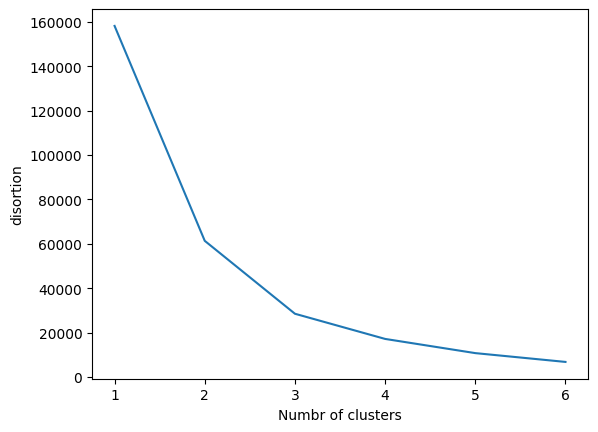

In [7]:
Disortion = []
for k in range(1,7):
  model = KMeans(n_clusters = k,init='k-means++',n_init=10)
  model.fit(X_pca)
  Disortion.append(model.inertia_)
plt.plot(range(1,7),Disortion)
plt.xlabel("Numbr of clusters")
plt.ylabel("disortion")
plt.show()

In [8]:
model = KMeans(n_clusters=3,init='k-means++',random_state=42,n_init=10)
model.fit(X_pca)
y = model.predict(X_pca)

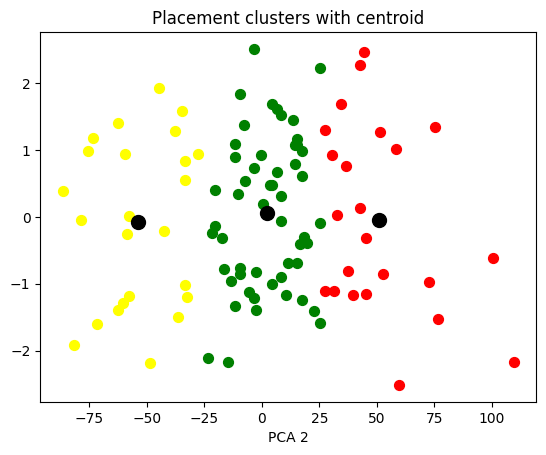

In [9]:
plt.scatter(X_pca[y==0,0],X_pca[y==0,1],s=50,c='red',label='Cluster 1')
plt.scatter(X_pca[y==1,0],X_pca[y==1,1],s=50,c='green',label='Cluster 2')
plt.scatter(X_pca[y==2,0],X_pca[y==2,1],s=50,c='yellow',label='Cluster 3')
plt.scatter(model.cluster_centers_[:,0],model.cluster_centers_[:,1],s=100,c='black',label='Centroids')
plt.title("Placement clusters with centroid")
plt.xlabel("PCA 1")
plt.xlabel("PCA 2")
plt.show()